# Fusion Oncology -- AI-Powered Cancer Target Discovery

**Author:** Kevin Thomas (ket189@pitt.edu)
| GitHub: [fusion_oncology](https://github.com/mytechnotalent/fusion_oncology)

## Pipeline Overview

| Layer | Technology | Purpose |
|---|---|---|
| Feature Engineering | Row-level statistics | Expression distribution |
| XGBoost + Optuna HPO | Gradient-boosted trees | Gene importance ranking |
| DNABERT-2 | Transformer embeddings | Instability scoring |
| Fusion Index | PCA-weighted embedding | Joint representation |
| Clinical Evidence | OpenTargets / CIViC | Literature validation |
| Drug-Target Mapping | 82-gene FDA database | Therapy identification |
| Digital Twin | Gompertzian ODE | Treatment simulation |
| Companion Dx | AMP/ASCO/CAP tiering | Patient-level planning |

**Dataset:** GDSC (Genomics of Drug Sensitivity in Cancer) --
1,002 cell lines with drug-sensitivity profiles.


## 1 -- Setup


In [1]:
# -- Environment variables (before any library import) --
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_CPP_MIN_VLOG_LEVEL"] = "3"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TF"] = "0"
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

In [2]:
# -- Install fusion-oncology from GitHub --
%pip install -q \
    "openpyxl>=3.1,<4" \
    "fusion-oncology @ git+https://github.com/mytechnotalent/fusion_oncology.git@main"
print("Installation complete")


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Installation complete


In [3]:
# -- Silence noisy third-party loggers --
import warnings
import logging

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*Precision.*")

from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
for _n in ("absl", "transformers", "transformers.modeling_utils"):
    logging.getLogger(_n).setLevel(logging.ERROR)
logging.getLogger("fusion_oncology").setLevel(logging.WARNING)

In [4]:
# -- Standard and project imports --
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

In [5]:
# -- Fusion Oncology imports --
from fusion_oncology.config import ProjectConfig
from fusion_oncology.models.fusion import FusionEngine
from fusion_oncology.analysis.clinical_evidence import (
    ClinicalEvidenceAggregator,
)
from fusion_oncology.analysis.drug_target import (
    DrugTargetMapper,
    DRUG_TARGET_DB,
)
from fusion_oncology.analysis.resistance import ResistancePredictor
from fusion_oncology.analysis.pathway import PathwayEnrichment
from fusion_oncology.models.digital_twin import (
    DigitalTwin,
    SimulationConfig,
    DrugRegimen,
)
from fusion_oncology.models.companion_dx import (
    PatientProfile,
    CompanionDiagnostic,
)

print(f"Drug DB covers {len(DRUG_TARGET_DB)} gene targets")

Drug DB covers 82 gene targets


## 2 -- Configuration


In [6]:
# -- Production-grade hyperparameters --
# enable_hpo=True  -> 50-trial Optuna Bayesian HPO
# top_k_genes=20   -> broader target discovery
# bert_pca_dims=64 -> retain more DNABERT-2 signal
cfg = ProjectConfig(
    top_k_genes=20,
    fuzz_iterations=30,
    xgb_n_estimators=1_000,
    xgb_max_depth=6,
    xgb_learning_rate=0.03,
    xgb_min_child_weight=5,
    xgb_gamma=0.2,
    xgb_reg_alpha=0.3,
    xgb_reg_lambda=2.0,
    min_class_size=40,
    enable_hpo=True,
    enable_feature_engineering=True,
    bert_pca_dims=64,
    output_dir=Path("/kaggle/working/results"),
)

In [7]:
# -- Print active settings --
print("Pipeline Configuration")
print("=" * 50)
print(f"  Top-K genes:       {cfg.top_k_genes}")
print(f"  Fuzz iterations:   {cfg.fuzz_iterations}")
print(f"  XGBoost trees:     {cfg.xgb_n_estimators}")
print(f"  Max depth:         {cfg.xgb_max_depth}")
print(f"  Learning rate:     {cfg.xgb_learning_rate}")
print(f"  Min class size:    {cfg.min_class_size}")
print(f"  DNABERT PCA dims:  {cfg.bert_pca_dims}")
print(f"  HPO enabled:       {cfg.enable_hpo}")

Pipeline Configuration
  Top-K genes:       20
  Fuzz iterations:   30
  XGBoost trees:     1000
  Max depth:         6
  Learning rate:     0.03
  Min class size:    40
  DNABERT PCA dims:  64
  HPO enabled:       True


## 3 -- Load GDSC Data

The GDSC dataset contains drug-sensitivity profiles (LN_IC50)
across 1,002 cancer cell lines.  We pivot TARGET columns into a
gene-level feature matrix.


In [8]:
# -- Read raw GDSC files --
GDSC_DIR = "/kaggle/input/genomics-of-drug-sensitivity-in-cancer-gdsc"

df_main = pd.read_csv(f"{GDSC_DIR}/GDSC_DATASET.csv")
df_gdsc2 = pd.read_csv(f"{GDSC_DIR}/GDSC2-dataset.csv")
df_compounds = pd.read_csv(f"{GDSC_DIR}/Compounds-annotation.csv")
df_cellinfo = pd.read_excel(
    f"{GDSC_DIR}/Cell_Lines_Details.xlsx",
    sheet_name="Cell line details",
)

In [9]:
# -- File summary --
print("GDSC Files Loaded")
print("=" * 50)
for name, df in [
    ("GDSC_DATASET.csv", df_main),
    ("GDSC2-dataset.csv", df_gdsc2),
    ("Compounds-annotation.csv", df_compounds),
    ("Cell_Lines_Details.xlsx", df_cellinfo),
]:
    print(f"  {name:30s}  {df.shape[0]:>6,} x {df.shape[1]:>3}")

GDSC Files Loaded
  GDSC_DATASET.csv                242,035 x  19
  GDSC2-dataset.csv               242,036 x  19
  Compounds-annotation.csv           621 x   6
  Cell_Lines_Details.xlsx          1,002 x  13


In [10]:
# -- Explode multi-target entries and pivot --
df_targets = df_main[["COSMIC_ID", "TCGA_DESC", "TARGET", "LN_IC50"]].dropna(
    subset=["TARGET", "LN_IC50", "TCGA_DESC"]
)

df_exploded = df_targets.assign(
    TARGET=df_targets["TARGET"].str.split(", "),
).explode("TARGET")
df_exploded["TARGET"] = df_exploded["TARGET"].str.strip()

pivot = df_exploded.pivot_table(
    index="COSMIC_ID",
    columns="TARGET",
    values="LN_IC50",
    aggfunc="mean",
)

In [11]:
# -- Build labels: majority cancer type per cell line --
cell_labels = (
    df_main.dropna(subset=["TCGA_DESC"])
    .groupby("COSMIC_ID")["TCGA_DESC"]
    .agg(lambda x: x.mode().iloc[0])
)

common_ids = pivot.index.intersection(cell_labels.index)
X = pivot.loc[common_ids].fillna(0)
y = cell_labels.loc[common_ids]

In [12]:
# -- Filter columns to valid gene symbols --
gene_coverage = (X != 0).sum()
X = X[gene_coverage[gene_coverage >= 10].index]

_GENE_RE = re.compile(r"^[A-Z][A-Z0-9/.:-]*(?:\s*\([^)]+\))?$")
gene_cols = [c for c in X.columns if _GENE_RE.match(c)]
X = X[gene_cols]

In [13]:
# -- Merge rare cancer types into OTHER --
type_counts = y.value_counts()
rare = type_counts[type_counts < cfg.min_class_size].index
y = y.replace({t: "OTHER" for t in rare})

other_n = (y == "OTHER").sum()
if other_n < cfg.min_class_size:
    mask = y != "OTHER"
    X, y = X.loc[mask], y.loc[mask]

druggable_in_features = set(X.columns) & set(DRUG_TARGET_DB)

In [14]:
# -- Feature matrix summary --
print("Feature Matrix Ready")
print("=" * 50)
print(f"  Cell lines:          {X.shape[0]:,}")
print(f"  Gene features:       {X.shape[1]:,}")
print(f"  Cancer types:        {y.nunique()}")
print(f"  Druggable in matrix: {len(druggable_in_features)}")
print()
print(y.value_counts().to_string())

Feature Matrix Ready
  Cell lines:          963
  Gene features:       193
  Cancer types:        7
  Druggable in matrix: 55

TCGA_DESC
OTHER           510
UNCLASSIFIED    181
LUAD             62
SCLC             59
SKCM             54
BRCA             51
COREAD           46


## 4 -- Exploratory Data Analysis


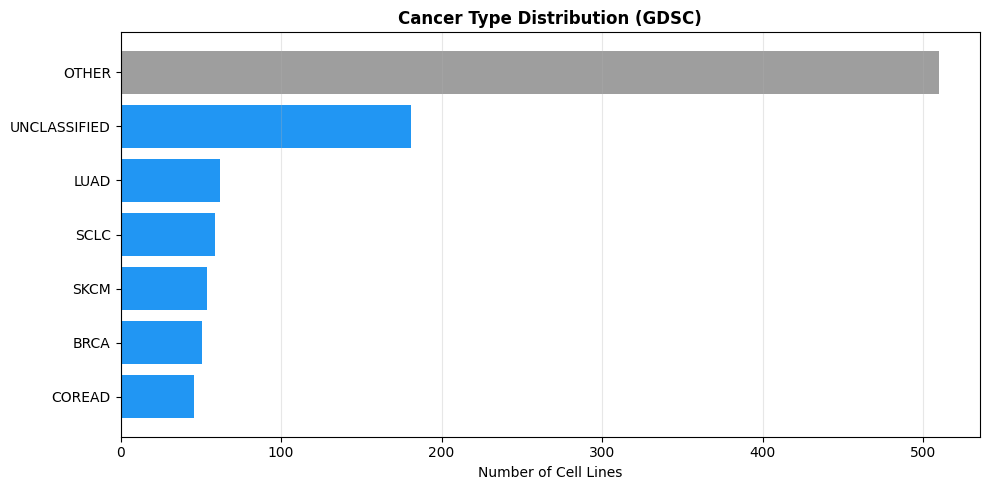

In [15]:
# -- Cancer-type distribution --
fig, ax = plt.subplots(figsize=(10, 5))
counts = y.value_counts()
colours = ["#2196F3" if c != "OTHER" else "#9E9E9E" for c in counts.index]
ax.barh(counts.index, counts.values, color=colours)
ax.set_xlabel("Number of Cell Lines")
ax.set_title("Cancer Type Distribution (GDSC)", fontweight="bold")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

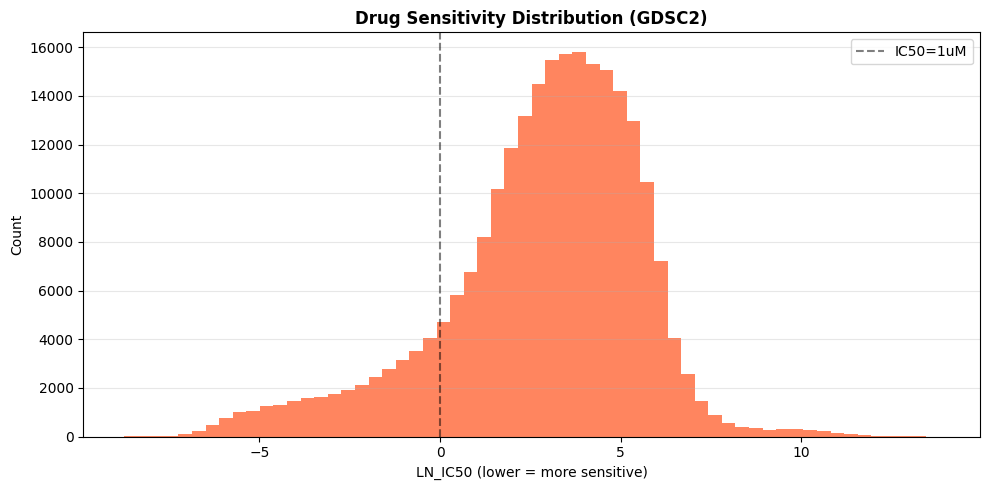

In [16]:
# -- Drug sensitivity distribution --
fig, ax = plt.subplots(figsize=(10, 5))
vals = df_gdsc2["LN_IC50"].dropna()
ax.hist(vals, bins=60, color="#FF7043", alpha=0.85)
ax.set_xlabel("LN_IC50 (lower = more sensitive)")
ax.set_ylabel("Count")
ax.set_title(
    "Drug Sensitivity Distribution (GDSC2)",
    fontweight="bold",
)
ax.axvline(x=0, color="black", ls="--", alpha=0.5, label="IC50=1uM")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

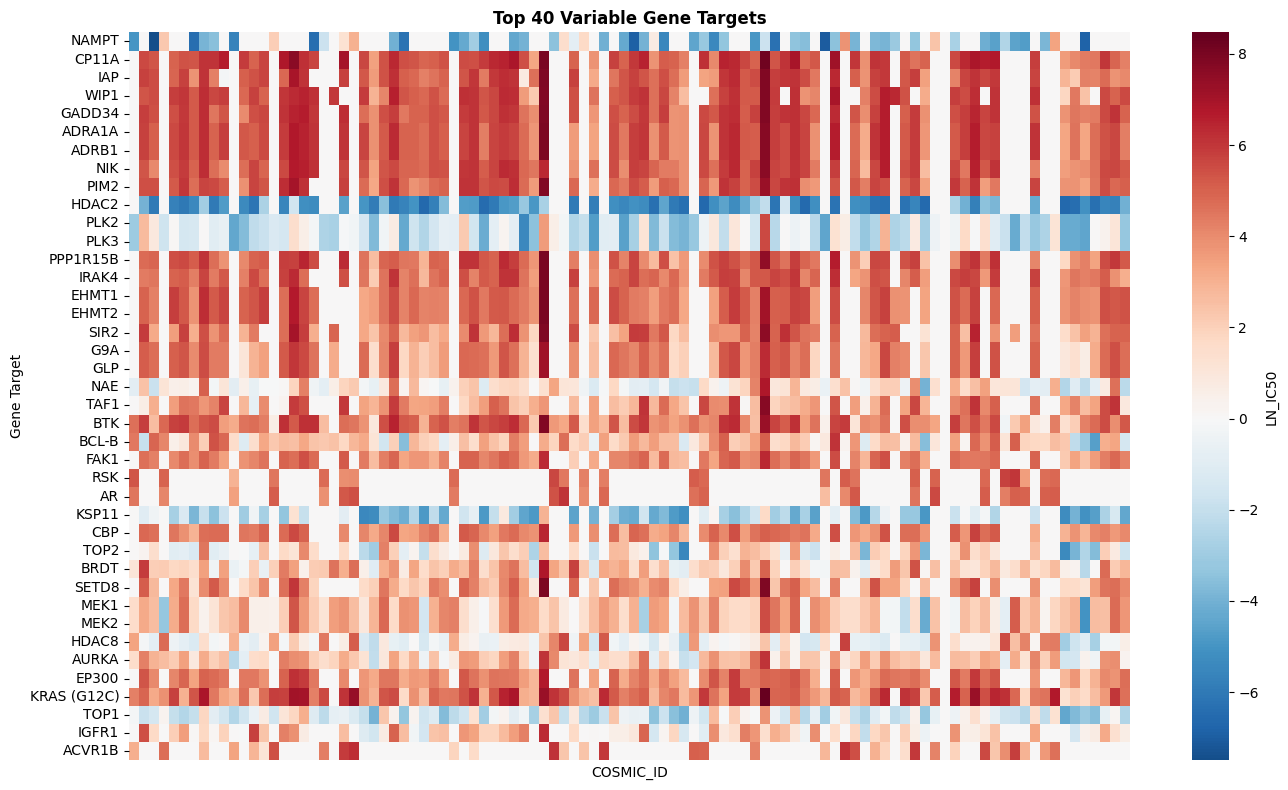

In [17]:
# -- Top-40 most variable gene targets heatmap --
top_var = X.var().nlargest(40).index
sample = X.sample(n=min(100, len(X)), random_state=42)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    sample[top_var].T,
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label": "LN_IC50"},
    ax=ax,
    xticklabels=False,
)
ax.set_title(
    "Top 40 Variable Gene Targets",
    fontweight="bold",
)
ax.set_ylabel("Gene Target")
plt.tight_layout()
plt.show()

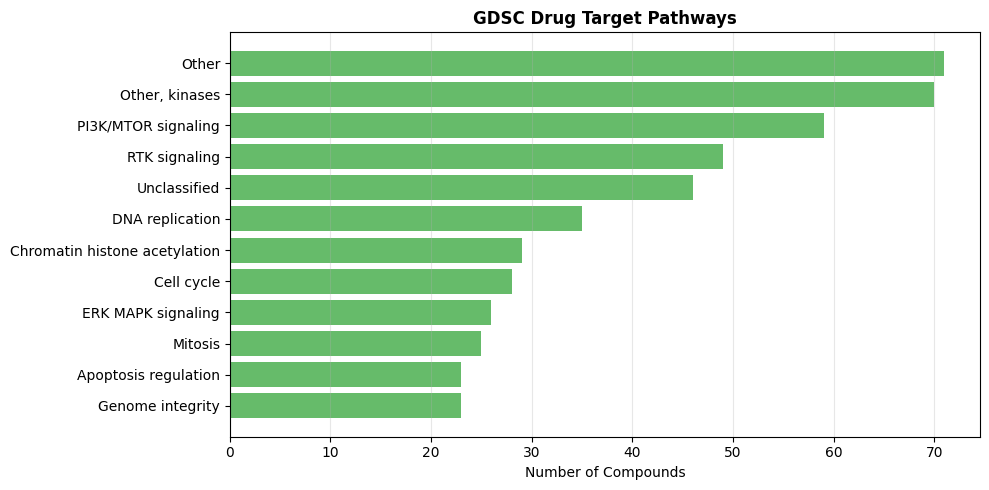

Unique drugs: 542  |  Pathways: 24


In [18]:
# -- Drug pathway breakdown --
if "TARGET_PATHWAY" in df_compounds.columns:
    pw = df_compounds["TARGET_PATHWAY"].value_counts().head(12)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(pw.index[::-1], pw.values[::-1], color="#66BB6A")
    ax.set_xlabel("Number of Compounds")
    ax.set_title("GDSC Drug Target Pathways", fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    n_drugs = df_compounds["DRUG_NAME"].nunique()
    n_paths = df_compounds["TARGET_PATHWAY"].nunique()
    print(f"Unique drugs: {n_drugs}  |  Pathways: {n_paths}")

## 5 -- Fusion Analysis (XGBoost + DNABERT-2)

1. XGBoost trains on drug-sensitivity features
2. DNABERT-2 computes 768-dim sequence embeddings
3. PCA compresses embeddings to 64 dims
4. Fusion features = sensitivity-weighted embeddings
5. Instability scoring via random SNP mutation drift
6. Fusion Index = Importance x Instability x 1000


In [19]:
# -- Run the full fusion pipeline --
print("Running Fusion Analysis (XGBoost + DNABERT-2)...")
print("Takes 3-5 minutes with Optuna HPO enabled.")

engine = FusionEngine(cfg)
results = engine.run(X, y)
top_genes = results["Gene"].tolist()

Running Fusion Analysis (XGBoost + DNABERT-2)...
Takes 3-5 minutes with Optuna HPO enabled.


tokenizer_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

configuration_bert.py: 0.00B [00:00, ?B/s]

bert_layers.py: 0.00B [00:00, ?B/s]

flash_attn_triton.py: 0.00B [00:00, ?B/s]

bert_padding.py: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/468M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/468M [00:00<?, ?B/s]

In [20]:
# -- Top therapeutic targets --
print(f"TOP {len(top_genes)} THERAPEUTIC TARGETS")
print("=" * 52)
header = f"{'Gene':>12s}  {'FusionIdx':>9s}  {'Imp':>6s}  {'Instab':>6s}"
print(header)
print("-" * 52)
for _, row in results.iterrows():
    print(
        f"{row['Gene']:>12s}  "
        f"{row['Fusion_Index']:9.4f}  "
        f"{row['XGB_Importance']:6.4f}  "
        f"{row['Instability']:6.4f}"
    )

TOP 20 THERAPEUTIC TARGETS
        Gene  FusionIdx     Imp  Instab
----------------------------------------------------
      ACVR1C     1.8996  0.0311  0.0611
      ACVR1B     1.2247  0.0288  0.0425
       EGLN1     1.0590  0.0228  0.0465
       AURKC     0.8096  0.0218  0.0372
       BCL-B     0.5565  0.0084  0.0664
          AR     0.5025  0.0519  0.0097
        WIP1     0.4733  0.0079  0.0601
        BCL2     0.3777  0.0103  0.0368
         RSK     0.2089  0.0453  0.0046
        MEK2     0.1231  0.0142  0.0086
        BRAF     0.0822  0.0165  0.0050
         IKK     0.0820  0.0222  0.0037
      TGFBR1     0.0808  0.0204  0.0040
       ROCK1     0.0797  0.0204  0.0039
       ADRB1     0.0777  0.0128  0.0061
        TBK1     0.0729  0.0134  0.0054
       EHMT1     0.0693  0.0175  0.0040
        S6K1     0.0636  0.0148  0.0043
       EHMT2     0.0573  0.0118  0.0048
        MEK1     0.0516  0.0101  0.0051


In [21]:
# -- Fusion cross-validation metrics --
fcv = engine.fusion_cv_metrics
print("FUSION MODEL CV (5-fold x 3 repeats)")
print("=" * 50)
for label, key in [
    ("Accuracy", "accuracy"),
    ("Precision", "precision"),
    ("Recall", "recall"),
    ("F1-Score", "f1"),
    ("F2-Score", "f2"),
    ("ROC AUC", "roc_auc"),
]:
    m = fcv.get(f"mean_{key}", 0)
    s = fcv.get(f"std_{key}", 0)
    bar = "#" * int(m * 40)
    print(f"  {label:>10s}: {m:.4f} +/- {s:.4f}  {bar}")

FUSION MODEL CV (5-fold x 3 repeats)
    Accuracy: 0.6625 +/- 0.0301  ##########################
   Precision: 0.6381 +/- 0.0362  #########################
      Recall: 0.6625 +/- 0.0301  ##########################
    F1-Score: 0.6365 +/- 0.0336  #########################
    F2-Score: 0.6495 +/- 0.0315  #########################
     ROC AUC: 0.8078 +/- 0.0290  ################################


In [22]:
# -- Baseline comparison --
bcv = engine.cv_metrics
print("Baseline XGBoost (no DNABERT-2):")
b_acc = bcv.get("mean_accuracy", 0)
b_f1 = bcv.get("mean_f1", 0)
print(f"  Accuracy: {b_acc:.4f}")
print(f"  F1-Score: {b_f1:.4f}")
delta = fcv.get("mean_f1", 0) - b_f1
sign = "+" if delta >= 0 else ""
print(f"  Fusion lift: {sign}{delta:.4f} F1")

Baseline XGBoost (no DNABERT-2):
  Accuracy: 0.6532
  F1-Score: 0.6391
  Fusion lift: -0.0025 F1


In [23]:
# -- DNABERT-2 embedding summary --
dm = engine.dnabert_metrics
print("DNABERT-2 Analysis")
print("=" * 50)
print(f"  Genes scored:  {dm.get('n_genes_scored', 0)}")
print(f"  Mean instab.:  {dm.get('mean_instability', 0):.6f}")
print(f"  Max instab.:   {dm.get('max_instability', 0):.6f}")
print(f"  SNR:           {dm.get('signal_noise_ratio', 0):.2f}")

n_hits = dm.get("n_driver_hits", 0)
n_total = dm.get("n_genes_scored", 0)
drivers = dm.get("driver_genes_found", [])
pct = 100 * n_hits / max(n_total, 1)
print(f"  Driver enrichment: {n_hits}/{n_total} ({pct:.0f}%)")
if drivers:
    print(f"  Drivers: {', '.join(drivers)}")

DNABERT-2 Analysis
  Genes scored:  20
  Mean instab.:  0.020989
  Max instab.:   0.066401
  SNR:           0.94
  Driver enrichment: 2/20 (10%)
  Drivers: AR, BRAF


## 6 -- Target Visualisation


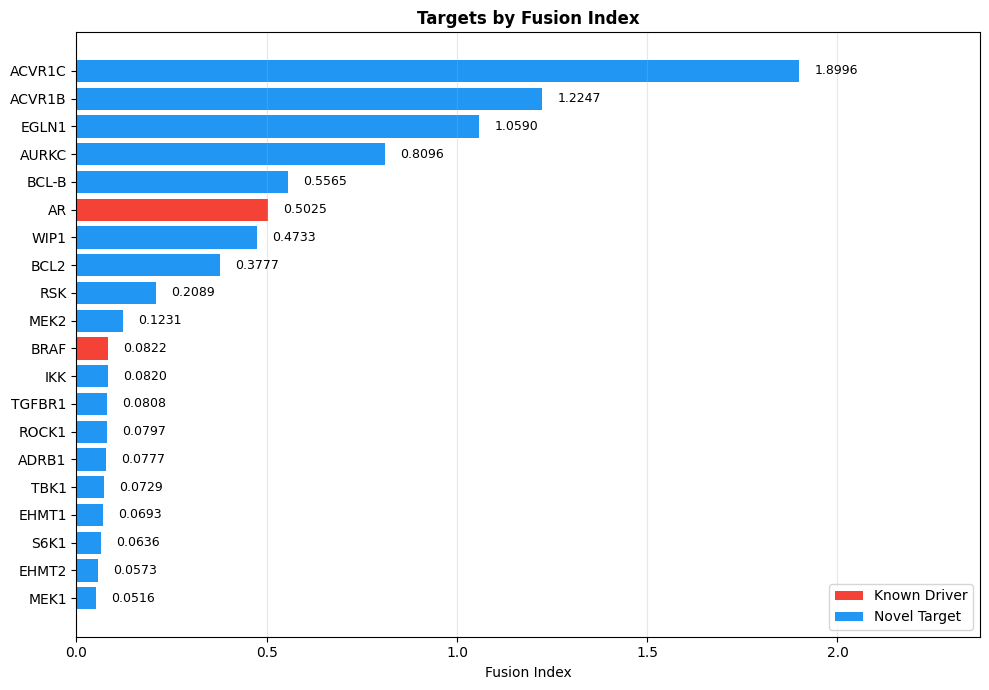

In [24]:
# -- Fusion Index ranking chart --
from matplotlib.patches import Patch

rs = results.sort_values("Fusion_Index", ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
colours = ["#F44336" if g in (drivers or []) else "#2196F3" for g in rs["Gene"]]
bars = ax.barh(rs["Gene"], rs["Fusion_Index"], color=colours)
for bar, val in zip(bars, rs["Fusion_Index"]):
    xpos = bar.get_width() + ax.get_xlim()[1] * 0.02
    ypos = bar.get_y() + bar.get_height() / 2
    ax.text(xpos, ypos, f"{val:.4f}", va="center", fontsize=9)
ax.set_xlabel("Fusion Index")
ax.set_title("Targets by Fusion Index", fontweight="bold")
ax.margins(x=0.25)
ax.grid(axis="x", alpha=0.3)
legend_h = [
    Patch(facecolor="#F44336", label="Known Driver"),
    Patch(facecolor="#2196F3", label="Novel Target"),
]
ax.legend(handles=legend_h, loc="lower right")
plt.tight_layout()
plt.show()

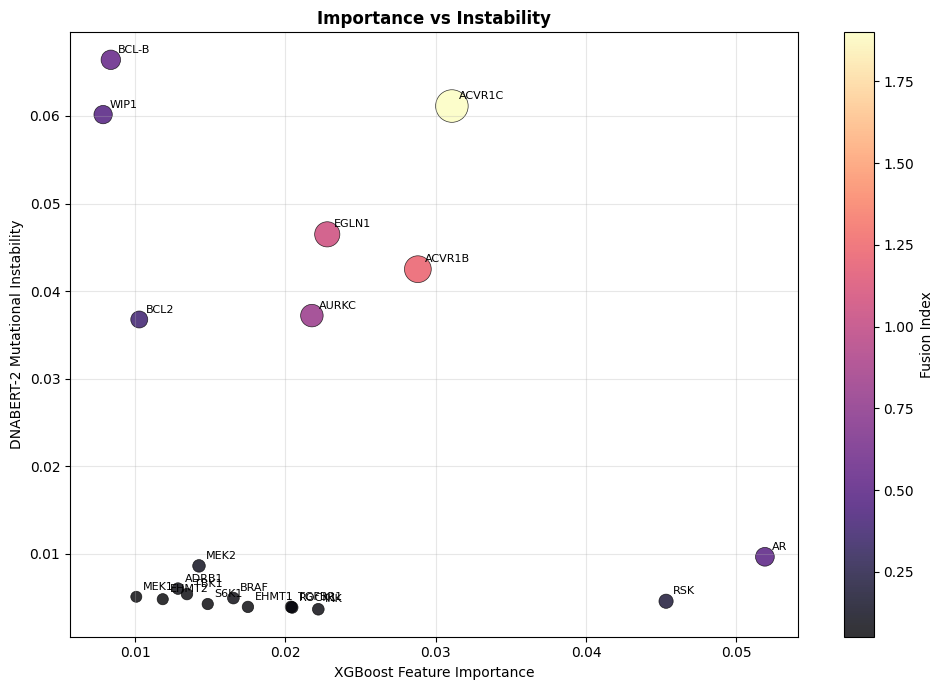

In [25]:
# -- Importance vs Instability scatter --
fig, ax = plt.subplots(figsize=(10, 7))
max_fi = max(results["Fusion_Index"].max(), 1e-6)
sizes = (results["Fusion_Index"] / max_fi) * 500 + 50
sc = ax.scatter(
    results["XGB_Importance"],
    results["Instability"],
    s=sizes,
    c=results["Fusion_Index"],
    cmap="magma",
    alpha=0.8,
    edgecolors="black",
    linewidth=0.5,
)
for _, row in results.iterrows():
    ax.annotate(
        row["Gene"],
        (row["XGB_Importance"], row["Instability"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )
ax.set_xlabel("XGBoost Feature Importance")
ax.set_ylabel("DNABERT-2 Mutational Instability")
ax.set_title("Importance vs Instability", fontweight="bold")
plt.colorbar(sc, label="Fusion Index")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7 -- Clinical Evidence and Drug Mapping

Query OpenTargets, CIViC, and ClinicalTrials.gov for each target.
Map to FDA-approved drugs from the curated 82-gene database.


In [26]:
# -- Clinical evidence for top 5 targets --
agg = ClinicalEvidenceAggregator(cfg)
evidence_cache: dict = {}

print(f"{'Gene':>10s}  {'OT':>5s}  {'Trials':>6s}  {'Comp':>5s}")
print("-" * 35)
for gene in top_genes[:5]:
    ev = agg.profile(gene)
    evidence_cache[gene] = ev
    ot = ev.get("opentargets", {}).get("overall_score", 0)
    nt = len(ev.get("trials", []))
    comp = ev.get("evidence_score", 0)
    print(f"{gene:>10s}  {ot:5.3f}  {nt:6d}  {comp:5.3f}")

      Gene     OT  Trials   Comp
-----------------------------------
    ACVR1C  0.500       0  0.200
    ACVR1B  0.488       0  0.195
     EGLN1  0.723       1  0.319
     AURKC  0.619       0  0.247
     BCL-B  0.333      20  0.433


In [27]:
# -- Drug-target mapping --
mapper = DrugTargetMapper(cfg)
drug_df = mapper.annotate(results)

In [28]:
# -- FDA-approved and investigational drugs --
print("FDA-APPROVED DRUGS")
print("=" * 50)
any_found = False
for _, row in drug_df.iterrows():
    drugs = row["Approved_Drugs"]
    if drugs and drugs != "—":
        print(f"  {row['Gene']:>10s}: {drugs}")
        any_found = True
if not any_found:
    print("  No approved drugs matched (novel targets)")

n_druggable = sum(
    1 for _, r in drug_df.iterrows() if r.get("Druggable", False) or r["Approved_Drugs"] != "—"
)
print(f"  Druggable: {n_druggable}/{len(drug_df)}")

FDA-APPROVED DRUGS
          AR: Enzalutamide; Abiraterone; Apalutamide; Darolutamide
        BCL2: Venetoclax
        BRAF: Vemurafenib; Dabrafenib; Encorafenib
       ROCK1: Fasudil; Ripasudil
  Druggable: 4/20


## 8 -- Resistance Mechanisms


In [29]:
# -- Resistance prediction for druggable targets --
predictor = ResistancePredictor(cfg)
drugged_genes = [g for g in top_genes if g in DRUG_TARGET_DB]

if drugged_genes:
    resist_df = predictor.full_report(drugged_genes)
    known = resist_df[resist_df["Mechanism"] != "None catalogued"]
    print(f"Resistance: {len(known)} entries")
    print("=" * 60)
    for _, row in known.iterrows():
        mech = row["Mechanism"]
        freq = row["Frequency"]
        print(f"  {row['Gene']:>10s}: {mech} ({freq})")
    if known.empty:
        print("  No catalogued resistance mechanisms")
else:
    print("No druggable targets -- skipping")

Resistance: 7 entries
          AR: AR amplification / AR-V7 splice variant (~20-30%)
          AR: Glucocorticoid receptor upregulation (~10-15%)
        BCL2: BCL2 G101V mutation (~15%)
        BCL2: MCL1 upregulation (~30%)
        BRAF: MAPK pathway reactivation (MEK/ERK) (~70%)
        BRAF: BRAF amplification (~10-15%)
        BRAF: RTK upregulation (EGFR, PDGFR) (~10-20%)


## 9 -- Pathway Enrichment


In [30]:
# -- Pathway enrichment analysis --
pathway_enricher = PathwayEnrichment(cfg)
pathway_df = pathway_enricher.annotate(results)

all_pathways: list[str] = []
for pw_list in pathway_df["Pathways"]:
    if pw_list != "—":
        all_pathways.extend(pw_list.split("; "))
pathway_counts = pd.Series(all_pathways).value_counts().head(12)

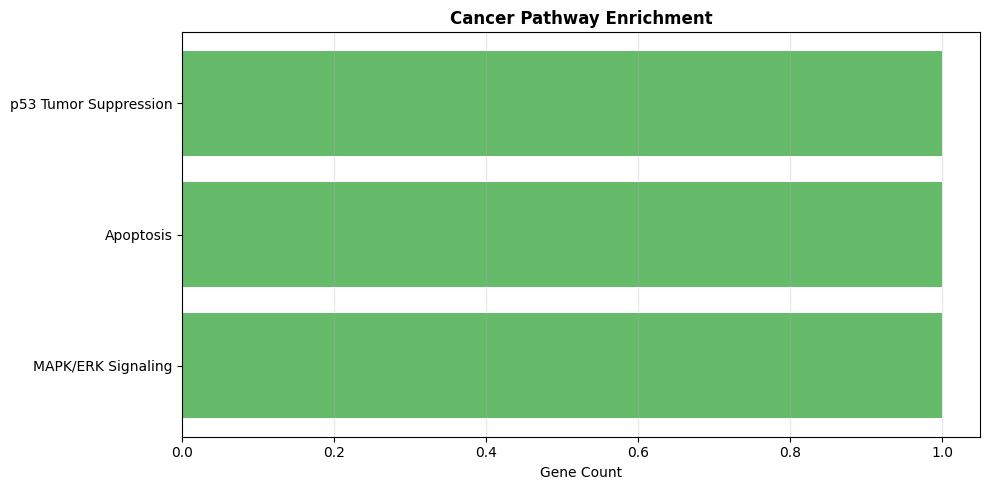

In [31]:
# -- Pathway enrichment chart --
fig, ax = plt.subplots(figsize=(10, 5))
if not pathway_counts.empty:
    ax.barh(
        pathway_counts.index[::-1],
        pathway_counts.values[::-1],
        color="#66BB6A",
    )
    ax.set_xlabel("Gene Count")
    ax.set_title(
        "Cancer Pathway Enrichment",
        fontweight="bold",
    )
    ax.grid(axis="x", alpha=0.3)
else:
    ax.text(
        0.5,
        0.5,
        "No pathway matches",
        transform=ax.transAxes,
        ha="center",
        fontsize=14,
    )
plt.tight_layout()
plt.show()

## 10 -- Digital Twin Tumour Simulation

Gompertzian growth ODE with combination therapy,
immune dynamics, and resistance emergence.


In [32]:
# -- Configure combination therapy --
sim_cfg = SimulationConfig(
    simulation_days=180,
    immune_kill_rate=1e-9,
    resistant_fraction=0.005,
)
twin = DigitalTwin(sim_config=sim_cfg, project_config=cfg)

twin.add_regimen(
    DrugRegimen(
        name="Targeted Therapy",
        efficacy=0.30,
        resistance_rate=0.0003,
        duration_days=180,
    )
)
twin.add_regimen(
    DrugRegimen(
        name="Combination Agent",
        efficacy=0.12,
        resistance_rate=0.0005,
        duration_days=120,
    )
)

In [33]:
# -- Run simulation --
trajectory = twin.simulate()
summary = twin.summary()

print("Digital Twin Results")
print("=" * 50)
best = summary["best_response"]
print(f"  RECIST:        {summary['recist']}")
print(f"  Best response: {best['response_pct']:.1f}% reduction")
print(f"  Best day:      {best.get('day', 'N/A')}")
print(f"  Final tumour:  {summary['final_tumour']:.2e} cells")
print(f"  Initial:       {summary['initial_tumour']:.2e} cells")

Digital Twin Results
  RECIST:        PR
  Best response: 88.8% reduction
  Best day:      11
  Final tumour:  7.05e+11 cells
  Initial:       1.00e+09 cells


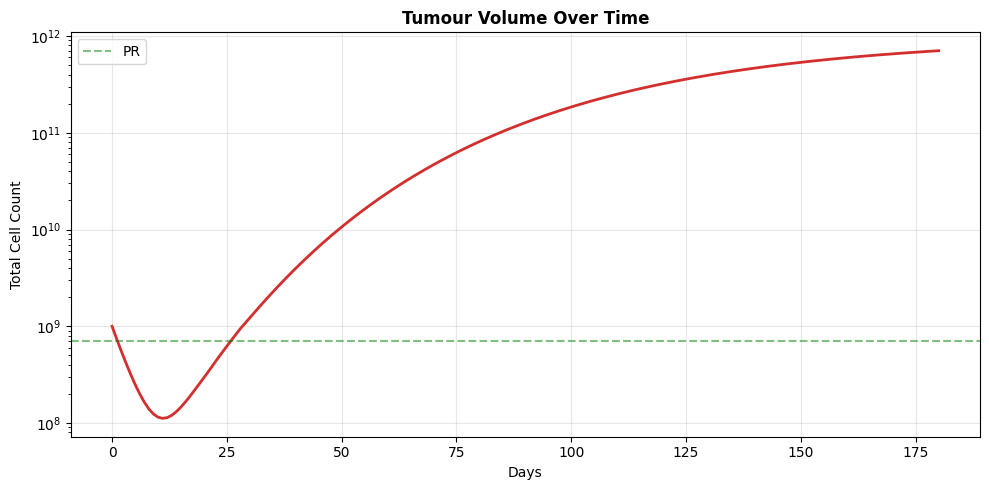

In [34]:
# -- Tumour volume over time --
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    trajectory["day"],
    trajectory["total"],
    color="#D32F2F",
    linewidth=2,
)
pr_line = summary["initial_tumour"] * 0.7
ax.axhline(y=pr_line, color="green", ls="--", alpha=0.5, label="PR")
ax.set_title("Tumour Volume Over Time", fontweight="bold")
ax.set_xlabel("Days")
ax.set_ylabel("Total Cell Count")
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

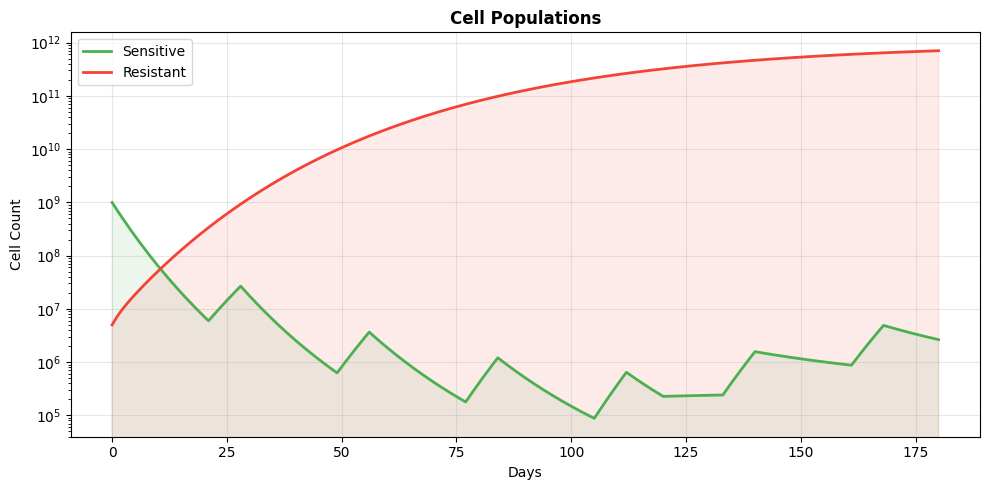

In [35]:
# -- Sensitive vs resistant cell populations --
days = trajectory["day"]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(days, trajectory["sensitive"], label="Sensitive", color="#4CAF50", linewidth=2)
ax.plot(days, trajectory["resistant"], label="Resistant", color="#F44336", linewidth=2)
ax.fill_between(days, 0, trajectory["sensitive"], alpha=0.1, color="#4CAF50")
ax.fill_between(days, 0, trajectory["resistant"], alpha=0.1, color="#F44336")
ax.set_title("Cell Populations", fontweight="bold")
ax.set_xlabel("Days")
ax.set_ylabel("Cell Count")
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11 -- Companion Diagnostics

Patient profile with driver mutations at clinical VAFs,
copy-number alterations, and high TMB for immunotherapy.


In [36]:
# -- Build clinically realistic patient profile --
top_gene = top_genes[0]
tissue = str(y.iloc[0])

patient = PatientProfile(
    patient_id="GDSC-DEMO-001",
    cancer_type=tissue,
    mutations=[
        {"gene": "EGFR", "variant": "L858R", "vaf": 0.42},
        {"gene": "BRAF", "variant": "V600E", "vaf": 0.35},
        {"gene": "KRAS", "variant": "G12D", "vaf": 0.28},
        {"gene": "TP53", "variant": "R175H", "vaf": 0.55},
        {"gene": "PIK3CA", "variant": "H1047R", "vaf": 0.31},
        {"gene": top_gene, "variant": "V600E", "vaf": 0.35},
        {"gene": "ATM", "variant": "R3008H", "vaf": 0.20},
        {"gene": "BRCA2", "variant": "E1143fs", "vaf": 0.45},
        {"gene": "CDK4", "variant": "R24C", "vaf": 0.18},
        {"gene": "FGFR3", "variant": "S249C", "vaf": 0.22},
        {"gene": "MET", "variant": "Y1003F", "vaf": 0.15},
        {"gene": "RET", "variant": "M918T", "vaf": 0.30},
    ],
    cna={"MYC": 2.1, "CDKN2A": -1.5, "ERBB2": 1.8},
)

In [37]:
# -- Patient summary --
print(f"Patient: {patient.patient_id}")
print(f"  Cancer type: {patient.cancer_type}")
print(f"  Mutations:   {len(patient.mutations)}")
print(f"  TMB:         {patient.tumour_mutational_burden}")
print(f"  CNAs:        {len(patient.cna)}")

Patient: GDSC-DEMO-001
  Cancer type: OTHER
  Mutations:   12
  TMB:         12
  CNAs:        3


In [38]:
# -- Generate companion diagnostic report --
dx = CompanionDiagnostic(cfg)
report = dx.analyse(patient)

In [39]:
# -- Actionable mutations --
actionable = report.get("actionable_mutations", [])
tier_1 = [m for m in actionable if m.get("tier") == "I"]
tier_2 = [m for m in actionable if m.get("tier") == "II"]

print("COMPANION DIAGNOSTIC REPORT")
print("=" * 50)
print(f"  Tier I  (strong evidence): {len(tier_1)}")
print(f"  Tier II (potential):       {len(tier_2)}")
for m in tier_1[:5]:
    gene = m["gene"]
    var = m.get("variant", "")
    print(f"    {gene} {var} -> {m.get('tier', '')}")

COMPANION DIAGNOSTIC REPORT
  Tier I  (strong evidence): 9
  Tier II (potential):       0
    EGFR L858R -> I
    BRAF V600E -> I
    KRAS G12D -> I
    PIK3CA H1047R -> I
    BRCA2 E1143fs -> I


In [40]:
# -- Treatment recommendations --
plan = report.get("treatment_plan", [])
print(f"Treatment Recommendations: {len(plan)}")
print("-" * 50)
for i, rec in enumerate(plan[:8], 1):
    conf = rec.get("confidence", 0)
    bar = "#" * int(conf * 20)
    therapy = rec["therapy"]
    rtype = rec.get("type", "N/A")
    print(f"  {i:2d}. {therapy:30s} {conf:.0%} {bar}")
    print(f"      Type: {rtype}")

Treatment Recommendations: 30
--------------------------------------------------
   1. Vemurafenib                    90% ##################
      Type: targeted
   2. Dabrafenib                     90% ##################
      Type: targeted
   3. Encorafenib                    90% ##################
      Type: targeted
   4. Olaparib                       90% ##################
      Type: targeted
   5. Niraparib                      90% ##################
      Type: targeted
   6. Palbociclib                    90% ##################
      Type: targeted
   7. Ribociclib                     90% ##################
      Type: targeted
   8. Erlotinib                      90% ##################
      Type: targeted


In [41]:
# -- Resistance alerts --
alerts = report.get("resistance_alerts", [])
if alerts:
    print(f"Resistance Alerts: {len(alerts)}")
    for a in alerts[:3]:
        gene = a.get("gene", "")
        mech = a.get("mechanism", "")
        print(f"  {gene}: {mech}")

Resistance Alerts: 17
  EGFR: T790M gatekeeper mutation
  EGFR: C797S mutation
  EGFR: MET amplification bypass


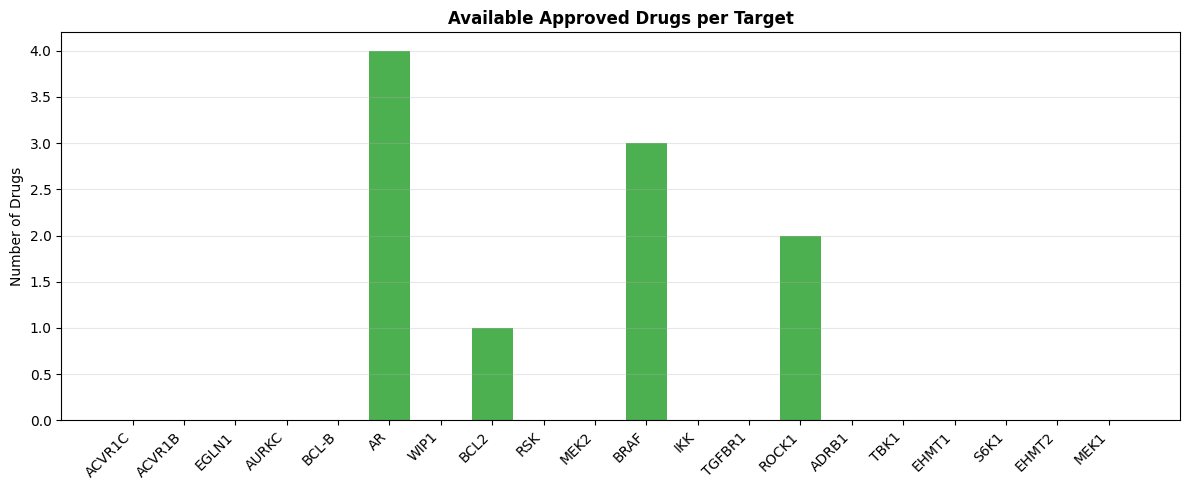

Targets with approved drugs: 4/20


In [42]:
# -- Drug availability chart --
drug_counts = drug_df["Approved_Drugs"].apply(
    lambda x: 0 if x == "—" else len(x.split("; ")),
)
fig, ax = plt.subplots(figsize=(12, 5))
colours = ["#4CAF50" if c > 0 else "#BDBDBD" for c in drug_counts]
ax.bar(drug_df["Gene"], drug_counts, color=colours)
ax.set_title(
    "Available Approved Drugs per Target",
    fontweight="bold",
)
ax.set_ylabel("Number of Drugs")
plt.xticks(rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

n_with = (drug_counts > 0).sum()
print(f"Targets with approved drugs: {n_with}/{len(drug_counts)}")

## 12 -- End-to-End Inference Summary

Single summary of all 9 pipeline stages.


In [43]:
# -- Stage 1-3: Data + Fusion --
print("=" * 60)
print("FUSION ONCOLOGY -- INFERENCE SUMMARY")
print("=" * 60)
print(f"  Cell lines:  {X.shape[0]:,}")
print(f"  Genes:       {X.shape[1]:,}")
print(f"  Top targets: {len(top_genes)}")
for _, row in results.head(5).iterrows():
    print(f"    {row['Gene']:>10s}  " f"FI={row['Fusion_Index']:.4f}")

FUSION ONCOLOGY -- INFERENCE SUMMARY
  Cell lines:  963
  Genes:       193
  Top targets: 20
        ACVR1C  FI=1.8996
        ACVR1B  FI=1.2247
         EGLN1  FI=1.0590
         AURKC  FI=0.8096
         BCL-B  FI=0.5565


In [44]:
# -- Stage 4-5: Metrics + Evidence --
print("Cross-Validation Metrics")
for label, key in [("Acc", "accuracy"), ("F1", "f1"), ("AUC", "roc_auc")]:
    m = fcv.get(f"mean_{key}", 0)
    s = fcv.get(f"std_{key}", 0)
    print(f"  {label:>4s}: {m:.4f} +/- {s:.4f}")

print()
print("Clinical Evidence (top 3)")
for gene in top_genes[:3]:
    ev = evidence_cache.get(gene) or agg.profile(gene)
    score = ev.get("evidence_score", 0)
    print(f"  {gene:>10s}: {score:.3f}")

Cross-Validation Metrics
   Acc: 0.6625 +/- 0.0301
    F1: 0.6365 +/- 0.0336
   AUC: 0.8078 +/- 0.0290

Clinical Evidence (top 3)
      ACVR1C: 0.200
      ACVR1B: 0.195
       EGLN1: 0.319


In [45]:
# -- Stage 6-7: Drugs + Resistance --
print("FDA Drugs for Top Targets")
for _, row in drug_df.iterrows():
    if row["Approved_Drugs"] != "—":
        print(f"  {row['Gene']:>10s}: {row['Approved_Drugs']}")

if drugged_genes:
    r = predictor.full_report(drugged_genes[:5])
    known_r = r[r["Mechanism"] != "None catalogued"]
    print(f"  Resistance entries: {len(known_r)}")

FDA Drugs for Top Targets
          AR: Enzalutamide; Abiraterone; Apalutamide; Darolutamide
        BCL2: Venetoclax
        BRAF: Vemurafenib; Dabrafenib; Encorafenib
       ROCK1: Fasudil; Ripasudil
  Resistance entries: 4


In [46]:
# -- Stage 8-9: Simulation + Companion Dx --
print(f"Digital Twin: {summary['recist']}")
best = summary["best_response"]
print(f"  Best response: {best['response_pct']:.1f}% reduction")

print(f"Companion Dx: {len(plan)} recommendations")
for rec in plan[:3]:
    conf = rec.get("confidence", 0)
    print(f"  - {rec['therapy']} ({conf:.0%})")

print()
print(f"Driver enrichment: {n_hits}/{n_total}")
if drivers:
    print(f"  Drivers: {', '.join(drivers)}")

Digital Twin: PR
  Best response: 88.8% reduction
Companion Dx: 30 recommendations
  - Vemurafenib (90%)
  - Dabrafenib (90%)
  - Encorafenib (90%)

Driver enrichment: 2/20
  Drivers: AR, BRAF


In [47]:
# -- Final status --
print("=" * 60)
print("INFERENCE COMPLETE -- All 9 stages executed")
print("=" * 60)
top_ev = evidence_cache.get(top_genes[0], {})
top_drugs_val = drug_df.iloc[0]["Approved_Drugs"]
print(f"  Top target:   {top_genes[0]}")
fi_val = results.iloc[0]["Fusion_Index"]
print(f"  Fusion Index: {fi_val:.4f}")
ev_score = top_ev.get("evidence_score", 0)
print(f"  Evidence:     {ev_score:.3f}/1.0")
drug_str = top_drugs_val if top_drugs_val != "—" else "Research"
print(f"  Drugs:        {drug_str}")
print(f"  RECIST:       {summary['recist']}")
print(f"  Tx Recs:      {len(plan)}")

INFERENCE COMPLETE -- All 9 stages executed
  Top target:   ACVR1C
  Fusion Index: 1.8996
  Evidence:     0.200/1.0
  Drugs:        Research
  RECIST:       PR
  Tx Recs:      30


---

## Pipeline Summary

| Stage | Component | Output |
|---|---|---|
| 1 | XGBoost + Feature Engineering | Gene importance ranking |
| 2 | DNABERT-2 Embeddings | 768-dim representations |
| 3 | PCA Fusion | Importance-weighted context |
| 4 | Optuna HPO | Bayesian hyperparameters |
| 5 | Clinical Evidence | OpenTargets / CIViC scores |
| 6 | Drug Mapping | FDA therapies (82-gene DB) |
| 7 | Resistance Prediction | Known mechanisms |
| 8 | Digital Twin | ODE tumour simulation |
| 9 | Companion Diagnostics | AMP/ASCO/CAP tiered plan |

**Disclaimer:** Research tool for hypothesis generation --
not a clinical diagnostic device. Not FDA approved.


## Resources

**GitHub:**
[github.com/mytechnotalent/fusion_oncology](https://github.com/mytechnotalent/fusion_oncology)

```bibtex
@software{fusion_oncology_2026,
  title={Fusion Oncology: Multi-Modal AI for Cancer Target Discovery},
  author={Thomas, Kevin},
  year={2026},
  url={https://github.com/mytechnotalent/fusion_oncology}
}
```

**License:** MIT  |  **Contact:** @mytechnotalent
